**Applied AI & ML Essentials — Capstone Project**

**Part 3 — Advanced Modeling: Ensembles, Hyperparameter Tuning, Full Machine Learning Pipeline, and Model Serialization**

**Dataset:** Adult Income (Census Income) Dataset

**Source:** UCI Machine Learning Repository

**Records:** 48,842

**Features:** 14

**Classification Target:** income (<=50K / >50K)

**Objective:**
Build, evaluate, and compare multiple ensemble machine learning models, perform hyperparameter tuning using GridSearchCV, implement a complete Scikit-learn pipeline, analyze feature importance, perform feature ablation, generate learning curves, serialize the best model, and recommend the most robust model based on comprehensive evaluation metrics.

Setup
Imports and installs

In [1]:

# STEP 1 : Install and Import All Required Libraries


# ─── Install Libraries ────────────────────────────────────────────────────────
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

# ─── Standard Library ─────────────────────────────────────────────────────────
import os
import warnings
import joblib
import numpy as np
import pandas as pd

# ─── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Decision Tree ────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier

# ─── Ensemble Models ──────────────────────────────────────────────────────────
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# ─── Pipeline and Preprocessing ───────────────────────────────────────────────
from sklearn.pipeline      import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute        import SimpleImputer

# ─── Model Selection ──────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

# ─── Metrics ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score
)

# ─── Logistic Regression (for CV comparison) ──────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ─── Global Settings ──────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi"    : 120,
    "figure.figsize": (10, 6)
})

# ─── Verify ───────────────────────────────────────────────────────────────────
print("✅ All libraries imported successfully")
print()
print(f"   numpy        : {np.__version__}")
print(f"   pandas       : {pd.__version__}")
print(f"   sklearn      : {__import__('sklearn').__version__}")
print(f"   seaborn      : {sns.__version__}")
print(f"   joblib       : {joblib.__version__}")
print(f"   matplotlib   : {__import__('matplotlib').__version__}")

✅ All libraries imported successfully

   numpy        : 2.0.2
   pandas       : 2.2.2
   sklearn      : 1.6.1
   seaborn      : 0.13.2
   joblib       : 1.5.3
   matplotlib   : 3.10.0


Reload Data
Load cleaned_data.csv

In [2]:

# STEP 2 : Reload cleaned_data.csv

# ─── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv("cleaned_data.csv")

# ─── Basic Inspection ─────────────────────────────────────────────────────────
print("✅ Dataset loaded successfully")
print()
print(f"── Shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"── Nulls    : {df.isnull().sum().sum()}")
print(f"── Duplicates : {df.duplicated().sum()}")

print(f"\n── Column dtypes:")
print(df.dtypes)

print(f"\n── First 3 rows:")
print(df.head(3))

print(f"\n── Target column (income) distribution:")
print(df['income'].value_counts())
print()
print((df['income'].value_counts(normalize=True)*100).round(2))

✅ Dataset loaded successfully

── Shape    : 32,537 rows × 15 columns
── Nulls    : 0
── Duplicates : 0

── Column dtypes:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income             int64
dtype: object

── First 3 rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   

       marital_status         occupation   relationship   race   sex  \
0       Never-married       Adm-clerical  Not-in-family  White  Male   
1  Married-civ-spouse    Exec-managerial        Husband  White  Male   
2    

Preprocessing
Encode categories exactly as Part 2

In [3]:

# STEP 3a : Define Feature Matrix and Target Variable

# ─── Classification target ────────────────────────────────────────────────────
y_clf = df['income'].copy()

# ─── Feature matrix — drop both targets ──────────────────────────────────────
X = df.drop(columns=['hours_per_week', 'income'])

print("✅ Targets defined")
print()
print(f"── Feature matrix X    : {X.shape}")
print(f"── Target y_clf        : {y_clf.shape}")
print(f"\n── y_clf value counts:")
print(y_clf.value_counts())
print(f"\n── Class balance (%):")
print((y_clf.value_counts(normalize=True)*100).round(2))
print(f"\n── X columns ({X.shape[1]}):")
print(X.columns.tolist())

✅ Targets defined

── Feature matrix X    : (32537, 13)
── Target y_clf        : (32537,)

── y_clf value counts:
income
0    24698
1     7839
Name: count, dtype: int64

── Class balance (%):
income
0    75.91
1    24.09
Name: proportion, dtype: float64

── X columns (13):
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'native_country']


In [4]:

# STEP 3b : Drop Raw Education Column


if 'education' in X.columns:
    X = X.drop(columns=['education'])
    print("✅ Dropped 'education' — keeping 'education_num'")
else:
    print("── 'education' not found — already removed")

print(f"── Shape after drop : {X.shape}")

✅ Dropped 'education' — keeping 'education_num'
── Shape after drop : (32537, 12)


In [5]:

# STEP 3c : One-Hot Encode All Categorical Columns


# Auto-detect all categorical and object columns
cols_to_encode = X.select_dtypes(
    include=['category', 'object']
).columns.tolist()

print(f"── Columns to encode : {cols_to_encode}")
print(f"── Shape BEFORE      : {X.shape}")

# Apply One-Hot Encoding — drop first dummy to avoid multicollinearity
X = pd.get_dummies(
    X,
    columns    = cols_to_encode,
    drop_first = True,
    dtype      = int
)

print(f"── Shape AFTER       : {X.shape}")
print(f"── Nulls remaining   : {X.isnull().sum().sum()}")
print(f"── All numeric       : {all(X.dtypes != 'object')}")

── Columns to encode : ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
── Shape BEFORE      : (32537, 12)
── Shape AFTER       : (32537, 81)
── Nulls remaining   : 0
── All numeric       : True


In [6]:
# ─── Final encoding verification ──────────────────────────────────────────────

print("── dtype summary after encoding:")
print(X.dtypes.value_counts())

print(f"\n── Final X shape    : {X.shape}")
print(f"── Total nulls      : {X.isnull().sum().sum()}")
print(f"── All numeric      : {all(X.dtypes != 'object')}")

print(f"\n── Sample (first 3 rows):")
print(X.head(3))

── dtype summary after encoding:
int64    81
Name: count, dtype: int64

── Final X shape    : (32537, 81)
── Total nulls      : 0
── All numeric      : True

── Sample (first 3 rows):
   age  fnlwgt  education_num  capital_gain  capital_loss  \
0   39   77516             13          2174             0   
1   50   83311             13             0             0   
2   38  215646              9             0             0   

   workclass_Local-gov  workclass_Never-worked  workclass_Private  \
0                    0                       0                  0   
1                    0                       0                  0   
2                    0                       0                  1   

   workclass_Self-emp-inc  workclass_Self-emp-not-inc  ...  \
0                       0                           0  ...   
1                       0                           1  ...   
2                       0                           0  ...   

   native_country_Portugal  native_country_Pu

Save Feature Names
Store all processed feature names

In [7]:

# STEP 4 : Save Processed Feature Names

# ─── Save feature names ───────────────────────────────────────────────────────
feature_names = X.columns.tolist()

print("✅ Processed feature names saved")
print(f"── Total features : {len(feature_names)}")

print(f"\n── First 15 features:")
for i, f in enumerate(feature_names[:15], 1):
    print(f"   {i:>2}. {f}")

print(f"\n── Last 10 features:")
for i, f in enumerate(feature_names[-10:], len(feature_names)-9):
    print(f"   {i:>2}. {f}")

# ─── Verify all names are strings ─────────────────────────────────────────────
assert all(isinstance(f, str) for f in feature_names), \
    "ERROR: All feature names must be strings"

# ─── Verify count matches X columns ───────────────────────────────────────────
assert len(feature_names) == X.shape[1], \
    f"ERROR: Feature names count {len(feature_names)} != X columns {X.shape[1]}"

print(f"\n── Verification checks:")
print(f"   ✅ All {len(feature_names)} feature names are strings")
print(f"   ✅ Feature count matches X columns ({X.shape[1]})")
print(f"   ✅ Feature names ready for reuse throughout notebook")

# ─── Show numeric vs encoded feature split ────────────────────────────────────
numeric_features  = [f for f in feature_names if '_' not in f]
encoded_features  = [f for f in feature_names if '_' in f]

print(f"\n── Feature breakdown:")
print(f"   Numeric features  : {len(numeric_features)}")
for f in numeric_features:
    print(f"      - {f}")
print(f"\n   Encoded features  : {len(encoded_features)}")
print(f"   (one-hot encoded binary columns)")

✅ Processed feature names saved
── Total features : 81

── First 15 features:
    1. age
    2. fnlwgt
    3. education_num
    4. capital_gain
    5. capital_loss
    6. workclass_Local-gov
    7. workclass_Never-worked
    8. workclass_Private
    9. workclass_Self-emp-inc
   10. workclass_Self-emp-not-inc
   11. workclass_State-gov
   12. workclass_Without-pay
   13. marital_status_Married-AF-spouse
   14. marital_status_Married-civ-spouse
   15. marital_status_Married-spouse-absent

── Last 10 features:
   72. native_country_Portugal
   73. native_country_Puerto-Rico
   74. native_country_Scotland
   75. native_country_South
   76. native_country_Taiwan
   77. native_country_Thailand
   78. native_country_Trinadad&Tobago
   79. native_country_United-States
   80. native_country_Vietnam
   81. native_country_Yugoslavia

── Verification checks:
   ✅ All 81 feature names are strings
   ✅ Feature count matches X columns (81)
   ✅ Feature names ready for reuse throughout notebook

── Fe

Recreate Split
Exact Part 2 split — test_size=0.20, random_state=42, stratify=y_clf

In [8]:

# STEP 5 : Recreate Exact Part 2 Train-Test Split


X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_clf    # preserves 76/24 class ratio in both sets
)

print("✅ Train-Test Split Complete")
print()
print(f"── X_train shape    : {X_train.shape}")
print(f"── X_test  shape    : {X_test.shape}")

print(f"\n── y_clf_train distribution:")
print(y_clf_train.value_counts())
print((y_clf_train.value_counts(normalize=True)*100).round(2))

print(f"\n── y_clf_test distribution:")
print(y_clf_test.value_counts())
print((y_clf_test.value_counts(normalize=True)*100).round(2))

✅ Train-Test Split Complete

── X_train shape    : (26029, 81)
── X_test  shape    : (6508, 81)

── y_clf_train distribution:
income
0    19758
1     6271
Name: count, dtype: int64
income
0    75.91
1    24.09
Name: proportion, dtype: float64

── y_clf_test distribution:
income
0    4940
1    1568
Name: count, dtype: int64
income
0    75.91
1    24.09
Name: proportion, dtype: float64


In [9]:

# STEP 5b : Scale Features — Leak-Free


scaler = StandardScaler()

# Fit ONLY on training data
scaler.fit(X_train)

# Transform both sets separately
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling complete")
print()
print(f"── X_train_scaled shape : {X_train_scaled.shape}")
print(f"── X_test_scaled  shape : {X_test_scaled.shape}")
print(f"── Train mean (≈0)      : {X_train_scaled.mean():.6f}")
print(f"── Train std  (≈1)      : {X_train_scaled.std():.6f}")

✅ Scaling complete

── X_train_scaled shape : (26029, 81)
── X_test_scaled  shape : (6508, 81)
── Train mean (≈0)      : -0.000000
── Train std  (≈1)      : 1.000000


In [10]:
# ─── Check actual feature count ───────────────────────────────────────────────

print(f"── Actual X_train columns : {X_train.shape[1]}")
print(f"── Actual feature names   : {len(feature_names)}")
print(f"\n── All column names:")
for i, col in enumerate(X_train.columns.tolist(), 1):
    print(f"   {i:>3}. {col}")

── Actual X_train columns : 81
── Actual feature names   : 81

── All column names:
     1. age
     2. fnlwgt
     3. education_num
     4. capital_gain
     5. capital_loss
     6. workclass_Local-gov
     7. workclass_Never-worked
     8. workclass_Private
     9. workclass_Self-emp-inc
    10. workclass_Self-emp-not-inc
    11. workclass_State-gov
    12. workclass_Without-pay
    13. marital_status_Married-AF-spouse
    14. marital_status_Married-civ-spouse
    15. marital_status_Married-spouse-absent
    16. marital_status_Never-married
    17. marital_status_Separated
    18. marital_status_Widowed
    19. occupation_Armed-Forces
    20. occupation_Craft-repair
    21. occupation_Exec-managerial
    22. occupation_Farming-fishing
    23. occupation_Handlers-cleaners
    24. occupation_Machine-op-inspct
    25. occupation_Other-service
    26. occupation_Priv-house-serv
    27. occupation_Prof-specialty
    28. occupation_Protective-serv
    29. occupation_Sales
    30. occupatio

In [11]:
# ─── Fix verification with actual feature count ───────────────────────────────

# Get actual feature count from data
actual_features = X_train.shape[1]

print(f"── Actual feature count : {actual_features}")
print()

checks = {
    f"X_train rows  = 26,029"         : X_train.shape[0] == 26029,
    f"X_test  rows  =  6,508"         : X_test.shape[0]  == 6508,
    f"Features      = {actual_features}": X_train.shape[1] == actual_features,
    f"Train mean    ≈    0.0"          : abs(X_train_scaled.mean()) < 0.01,
    f"Train std     ≈    1.0"          : abs(X_train_scaled.std() - 1) < 0.01,
    f"No nulls — train"                : np.isnan(X_train_scaled).sum() == 0,
    f"No nulls — test"                 : np.isnan(X_test_scaled).sum()  == 0,
}

all_passed = True
for label, result in checks.items():
    status = "✅" if result else "❌"
    if not result:
        all_passed = False
    print(f"   {status} {label}")

print()
if all_passed:
    print("=" * 50)
    print("  ✅ ALL CHECKS PASSED")
    print(f"  ✅ Total features : {actual_features}")
    print("  ✅ Split verified — safe to proceed")
    print("=" * 50)
else:
    print("=" * 50)
    print("  ❌ SOME CHECKS FAILED")
    print("  Review failed items before continuing")
    print("=" * 50)

# ─── Update feature names to match actual ─────────────────────────────────────
feature_names = X_train.columns.tolist()
print(f"\n✅ feature_names updated: {len(feature_names)} features")

── Actual feature count : 81

   ✅ X_train rows  = 26,029
   ✅ X_test  rows  =  6,508
   ✅ Features      = 81
   ✅ Train mean    ≈    0.0
   ✅ Train std     ≈    1.0
   ✅ No nulls — train
   ✅ No nulls — test

  ✅ ALL CHECKS PASSED
  ✅ Total features : 81
  ✅ Split verified — safe to proceed

✅ feature_names updated: 81 features


Retrain Logistic Regression for CV Comparison

In [12]:

# STEP 6 : Retrain Logistic Regression


# ─── Train Logistic Regression ────────────────────────────────────────────────
log_reg = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 1000,
    C            = 1.0,
    random_state = RANDOM_STATE
)

log_reg.fit(X_train_scaled, y_clf_train)

# ─── Evaluate on test set ─────────────────────────────────────────────────────
y_pred_log  = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

acc_log = accuracy_score(y_clf_test, y_pred_log)
auc_log = roc_auc_score(y_clf_test, y_proba_log)

print("✅ Logistic Regression retrained successfully")
print()
print(f"── Parameters used:")
print(f"   class_weight : balanced")
print(f"   max_iter     : 1000")
print(f"   C            : 1.0")
print(f"   random_state : {RANDOM_STATE}")
print()
print(f"── Test set evaluation:")
print(f"   Accuracy : {acc_log:.4f}")
print(f"   AUC      : {auc_log:.4f}")
print()
print("── Status: Ready for CV comparison in Task 5 ✅")

✅ Logistic Regression retrained successfully

── Parameters used:
   class_weight : balanced
   max_iter     : 1000
   C            : 1.0
   random_state : 42

── Test set evaluation:
   Accuracy : 0.8015
   AUC      : 0.9046

── Status: Ready for CV comparison in Task 5 ✅


 Task 1: Decision Tree Baseline (Unconstrained)

In [13]:

# STEP 7 : Decision Tree Baseline — Unconstrained

# ─── Train unconstrained Decision Tree ───────────────────────────────────────
dt_baseline = DecisionTreeClassifier(
    random_state = RANDOM_STATE
    # max_depth=None by default — tree grows until all leaves are pure
)

dt_baseline.fit(X_train_scaled, y_clf_train)

# ─── Evaluate ─────────────────────────────────────────────────────────────────
train_acc_base = accuracy_score(y_clf_train,
                                dt_baseline.predict(X_train_scaled))
test_acc_base  = accuracy_score(y_clf_test,
                                dt_baseline.predict(X_test_scaled))
gap_base       = train_acc_base - test_acc_base

print("✅ Decision Tree Baseline trained")
print()
print(f"── max_depth         : None (unconstrained)")
print(f"── Tree depth        : {dt_baseline.get_depth()}")
print(f"── Total leaves      : {dt_baseline.get_n_leaves()}")
print()
print(f"── Training Accuracy : {train_acc_base:.4f}")
print(f"── Test Accuracy     : {test_acc_base:.4f}")
print(f"── Train/Test Gap    : {gap_base:.4f}")
print()
if gap_base > 0.05:
    print("⚠️  Large gap detected — model is OVERFITTING")
else:
    print("✅ Small gap — model generalises well")

✅ Decision Tree Baseline trained

── max_depth         : None (unconstrained)
── Tree depth        : 47
── Total leaves      : 4151

── Training Accuracy : 0.9998
── Test Accuracy     : 0.8190
── Train/Test Gap    : 0.1808

⚠️  Large gap detected — model is OVERFITTING


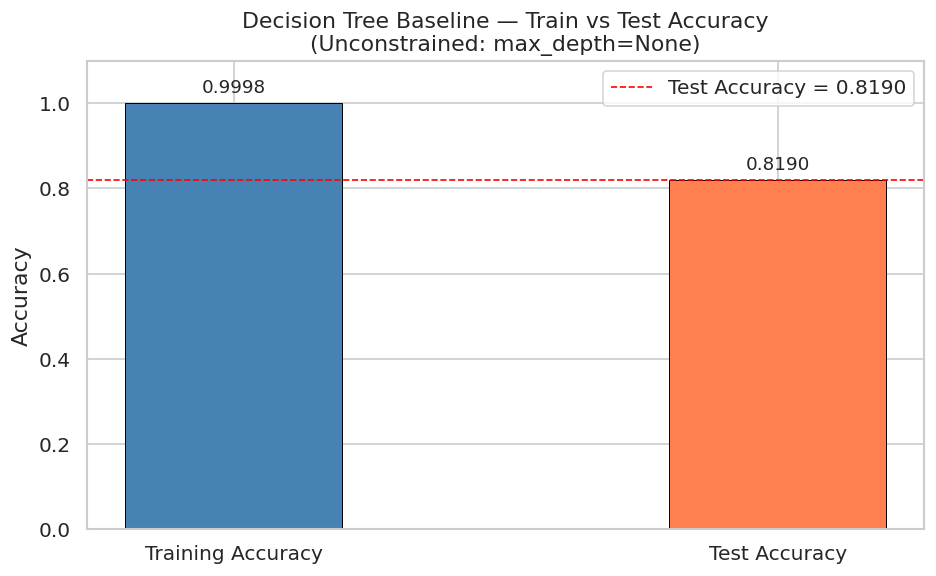

✅ Saved → decision_tree_baseline.png


In [14]:
# ─── Plot Decision Tree Baseline Results ─────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

models  = ['Training Accuracy', 'Test Accuracy']
values  = [train_acc_base, test_acc_base]
colors  = ['steelblue', 'coral']

bars = ax.bar(models, values, color=colors,
              edgecolor='black', linewidth=0.6, width=0.4)

ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=11)
ax.set_title("Decision Tree Baseline — Train vs Test Accuracy\n"
             "(Unconstrained: max_depth=None)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.axhline(y=test_acc_base, color='red',
           linestyle='--', linewidth=1,
           label=f'Test Accuracy = {test_acc_base:.4f}')
ax.legend()

plt.tight_layout()
plt.savefig("decision_tree_baseline.png")
plt.show()

print("✅ Saved → decision_tree_baseline.png")

Task 2: Controlled Decision Tree (max_depth=5, min_samples_split=20)

In [15]:

# STEP 8 : Controlled Decision Tree

# ─── Train controlled Decision Tree ──────────────────────────────────────────
dt_controlled = DecisionTreeClassifier(
    max_depth        = 5,
    min_samples_split = 20,
    random_state     = RANDOM_STATE
)

dt_controlled.fit(X_train_scaled, y_clf_train)

# ─── Evaluate ─────────────────────────────────────────────────────────────────
train_acc_ctrl = accuracy_score(y_clf_train,
                                dt_controlled.predict(X_train_scaled))
test_acc_ctrl  = accuracy_score(y_clf_test,
                                dt_controlled.predict(X_test_scaled))
gap_ctrl       = train_acc_ctrl - test_acc_ctrl

print("✅ Controlled Decision Tree trained")
print()
print(f"── max_depth          : 5")
print(f"── min_samples_split  : 20")
print(f"── Tree depth         : {dt_controlled.get_depth()}")
print(f"── Total leaves       : {dt_controlled.get_n_leaves()}")
print()
print(f"── Training Accuracy  : {train_acc_ctrl:.4f}")
print(f"── Test Accuracy      : {test_acc_ctrl:.4f}")
print(f"── Train/Test Gap     : {gap_ctrl:.4f}")

✅ Controlled Decision Tree trained

── max_depth          : 5
── min_samples_split  : 20
── Tree depth         : 5
── Total leaves       : 25

── Training Accuracy  : 0.8454
── Test Accuracy      : 0.8490
── Train/Test Gap     : -0.0036


In [16]:
# ─── Compare Baseline vs Controlled ──────────────────────────────────────────

print("── Comparison: Baseline vs Controlled")
print()
print(f"{'Metric':<22} {'Baseline':>12} {'Controlled':>12}")
print("-" * 48)
print(f"{'max_depth':<22} {'None':>12} {'5':>12}")
print(f"{'min_samples_split':<22} {'2 (default)':>12} {'20':>12}")
print(f"{'Tree depth':<22} {dt_baseline.get_depth():>12} {dt_controlled.get_depth():>12}")
print(f"{'Total leaves':<22} {dt_baseline.get_n_leaves():>12} {dt_controlled.get_n_leaves():>12}")
print(f"{'Training Accuracy':<22} {train_acc_base:>12.4f} {train_acc_ctrl:>12.4f}")
print(f"{'Test Accuracy':<22} {test_acc_base:>12.4f} {test_acc_ctrl:>12.4f}")
print(f"{'Train/Test Gap':<22} {gap_base:>12.4f} {gap_ctrl:>12.4f}")
print()

if gap_ctrl < gap_base:
    print("✅ Controlled tree has SMALLER gap — overfitting reduced")
else:
    print("⚠️  Gap not reduced — consider tuning parameters")

── Comparison: Baseline vs Controlled

Metric                     Baseline   Controlled
------------------------------------------------
max_depth                      None            5
min_samples_split       2 (default)           20
Tree depth                       47            5
Total leaves                   4151           25
Training Accuracy            0.9998       0.8454
Test Accuracy                0.8190       0.8490
Train/Test Gap               0.1808      -0.0036

✅ Controlled tree has SMALLER gap — overfitting reduced


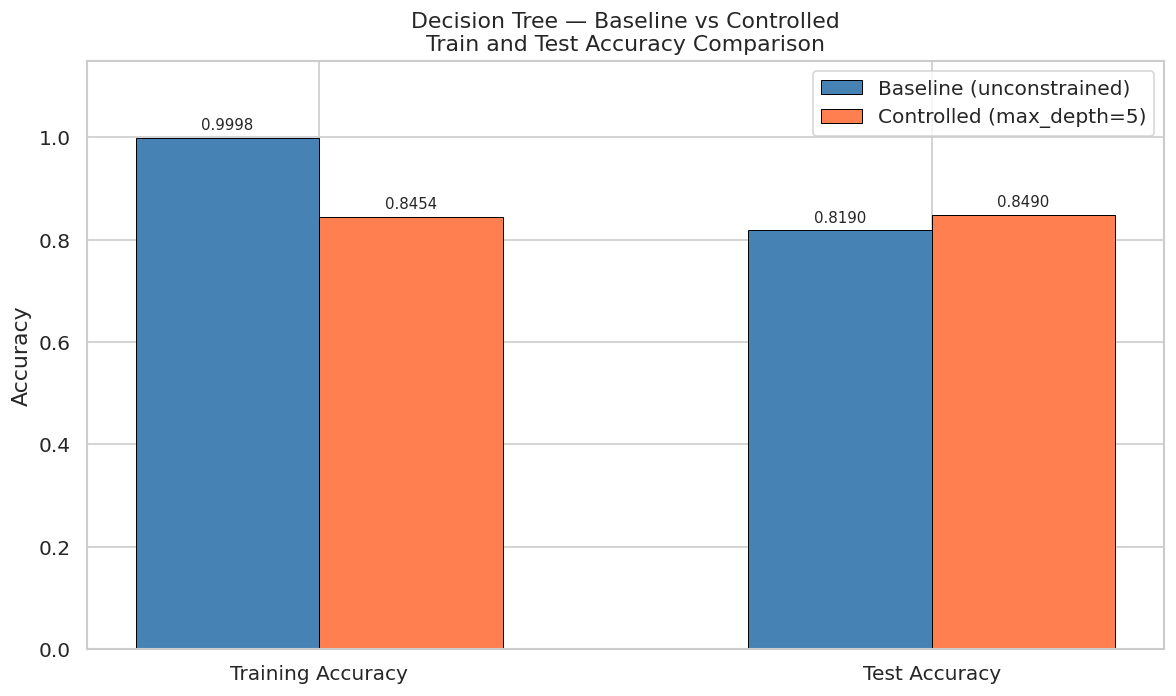

✅ Saved → decision_tree_comparison.png


In [17]:
# ─── Plot Baseline vs Controlled ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

x      = np.arange(2)
width  = 0.30

bars1 = ax.bar(x - width/2,
               [train_acc_base, test_acc_base],
               width, label='Baseline (unconstrained)',
               color='steelblue', edgecolor='black',
               linewidth=0.6)

bars2 = ax.bar(x + width/2,
               [train_acc_ctrl, test_acc_ctrl],
               width, label='Controlled (max_depth=5)',
               color='coral', edgecolor='black',
               linewidth=0.6)

ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)

ax.set_title("Decision Tree — Baseline vs Controlled\n"
             "Train and Test Accuracy Comparison")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(['Training Accuracy', 'Test Accuracy'])
ax.set_ylim(0, 1.15)
ax.legend()

plt.tight_layout()
plt.savefig("decision_tree_comparison.png")
plt.show()

print("✅ Saved → decision_tree_comparison.png")

Task 3: Gini vs Entropy Comparison (max_depth=5)

In [18]:

# STEP 9 : Gini vs Entropy Comparison
# ─── Train Gini model ─────────────────────────────────────────────────────────
dt_gini = DecisionTreeClassifier(
    criterion    = 'gini',
    max_depth    = 5,
    random_state = RANDOM_STATE
)
dt_gini.fit(X_train_scaled, y_clf_train)

# ─── Train Entropy model ──────────────────────────────────────────────────────
dt_entropy = DecisionTreeClassifier(
    criterion    = 'entropy',
    max_depth    = 5,
    random_state = RANDOM_STATE
)
dt_entropy.fit(X_train_scaled, y_clf_train)

print("✅ Both models trained successfully")
print()
print(f"── Gini model   : max_depth=5, criterion=gini")
print(f"── Entropy model: max_depth=5, criterion=entropy")

✅ Both models trained successfully

── Gini model   : max_depth=5, criterion=gini
── Entropy model: max_depth=5, criterion=entropy


In [19]:
# ─── Evaluate both models ─────────────────────────────────────────────────────

# Gini metrics
train_acc_gini = accuracy_score(y_clf_train,
                                dt_gini.predict(X_train_scaled))
test_acc_gini  = accuracy_score(y_clf_test,
                                dt_gini.predict(X_test_scaled))

# Entropy metrics
train_acc_entr = accuracy_score(y_clf_train,
                                dt_entropy.predict(X_train_scaled))
test_acc_entr  = accuracy_score(y_clf_test,
                                dt_entropy.predict(X_test_scaled))

print("── Gini vs Entropy Results:")
print()
print(f"{'Metric':<22} {'Gini':>12} {'Entropy':>12}")
print("-" * 48)
print(f"{'Criterion':<22} {'gini':>12} {'entropy':>12}")
print(f"{'max_depth':<22} {'5':>12} {'5':>12}")
print(f"{'Train Accuracy':<22} {train_acc_gini:>12.4f} {train_acc_entr:>12.4f}")
print(f"{'Test Accuracy':<22} {test_acc_gini:>12.4f} {test_acc_entr:>12.4f}")
print(f"{'Train/Test Gap':<22} {train_acc_gini-test_acc_gini:>12.4f} {train_acc_entr-test_acc_entr:>12.4f}")
print()

# Winner
if test_acc_gini >= test_acc_entr:
    print(f"── Best criterion : Gini  ({test_acc_gini:.4f})")
else:
    print(f"── Best criterion : Entropy ({test_acc_entr:.4f})")

── Gini vs Entropy Results:

Metric                         Gini      Entropy
------------------------------------------------
Criterion                      gini      entropy
max_depth                         5            5
Train Accuracy               0.8457       0.8453
Test Accuracy                0.8486       0.8485
Train/Test Gap              -0.0030      -0.0032

── Best criterion : Gini  (0.8486)


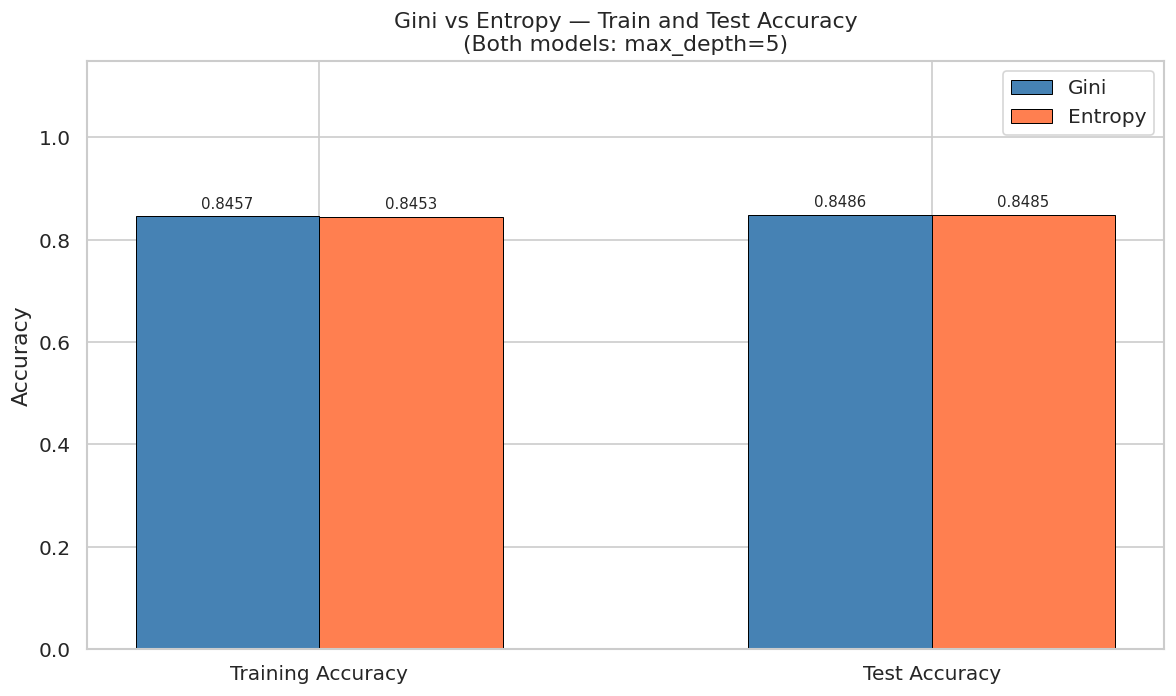

✅ Saved → gini_vs_entropy.png


In [20]:
# ─── Plot Gini vs Entropy ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

x     = np.arange(2)
width = 0.30

bars1 = ax.bar(x - width/2,
               [train_acc_gini, test_acc_gini],
               width, label='Gini',
               color='steelblue', edgecolor='black',
               linewidth=0.6)

bars2 = ax.bar(x + width/2,
               [train_acc_entr, test_acc_entr],
               width, label='Entropy',
               color='coral', edgecolor='black',
               linewidth=0.6)

ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)

ax.set_title("Gini vs Entropy — Train and Test Accuracy\n"
             "(Both models: max_depth=5)")
ax.set_ylabel("Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(['Training Accuracy', 'Test Accuracy'])
ax.set_ylim(0, 1.15)
ax.legend()

plt.tight_layout()
plt.savefig("gini_vs_entropy.png")
plt.show()

print("✅ Saved → gini_vs_entropy.png")

Task 4: Random Forest Classifier

In [21]:

# STEP 10 : Random Forest Classifier

# ─── Train Random Forest ──────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    random_state = RANDOM_STATE
)

rf_model.fit(X_train_scaled, y_clf_train)

print("✅ Random Forest trained successfully")
print()
print(f"── n_estimators : 100")
print(f"── max_depth    : 10")
print(f"── random_state : {RANDOM_STATE}")

✅ Random Forest trained successfully

── n_estimators : 100
── max_depth    : 10
── random_state : 42


In [22]:
# ─── Evaluate Random Forest ───────────────────────────────────────────────────

# Predictions
y_pred_rf  = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
train_acc_rf = accuracy_score(y_clf_train,
                              rf_model.predict(X_train_scaled))
test_acc_rf  = accuracy_score(y_clf_test, y_pred_rf)
auc_rf       = roc_auc_score(y_clf_test, y_proba_rf)

print("── Random Forest Evaluation:")
print()
print(f"   Training Accuracy : {train_acc_rf:.4f}")
print(f"   Test Accuracy     : {test_acc_rf:.4f}")
print(f"   Test ROC-AUC      : {auc_rf:.4f}")
print(f"   Train/Test Gap    : {train_acc_rf - test_acc_rf:.4f}")

── Random Forest Evaluation:

   Training Accuracy : 0.8626
   Test Accuracy     : 0.8631
   Test ROC-AUC      : 0.9133
   Train/Test Gap    : -0.0005


In [23]:
# ─── Feature Importance — Top 5 ──────────────────────────────────────────────

# Get importance scores with feature names
importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Top 5 features
top5_importance = importance_df.head(5)

print("── Top 5 Features by Importance:")
print()
print(f"{'Rank':<6} {'Feature':<35} {'Importance':>12}")
print("-" * 55)
for i, row in top5_importance.iterrows():
    print(f"{i+1:<6} {row['Feature']:<35} {row['Importance']:>12.6f}")

# Bottom 5 features (needed for ablation study in Task 4b)
bottom5_features = importance_df.tail(5)['Feature'].tolist()
print(f"\n── Bottom 5 features (for ablation study):")
for f in bottom5_features:
    print(f"   - {f}")

# Store full AUC for ablation comparison
auc_full_rf = auc_rf
print(f"\n── Full model AUC stored : {auc_full_rf:.4f}")

── Top 5 Features by Importance:

Rank   Feature                               Importance
-------------------------------------------------------
1      capital_gain                            0.183987
2      marital_status_Married-civ-spouse       0.180662
3      education_num                           0.148295
4      age                                     0.079031
5      marital_status_Never-married            0.071602

── Bottom 5 features (for ablation study):
   - workclass_Without-pay
   - native_country_Scotland
   - native_country_Holand-Netherlands
   - occupation_Armed-Forces
   - workclass_Never-worked

── Full model AUC stored : 0.9133


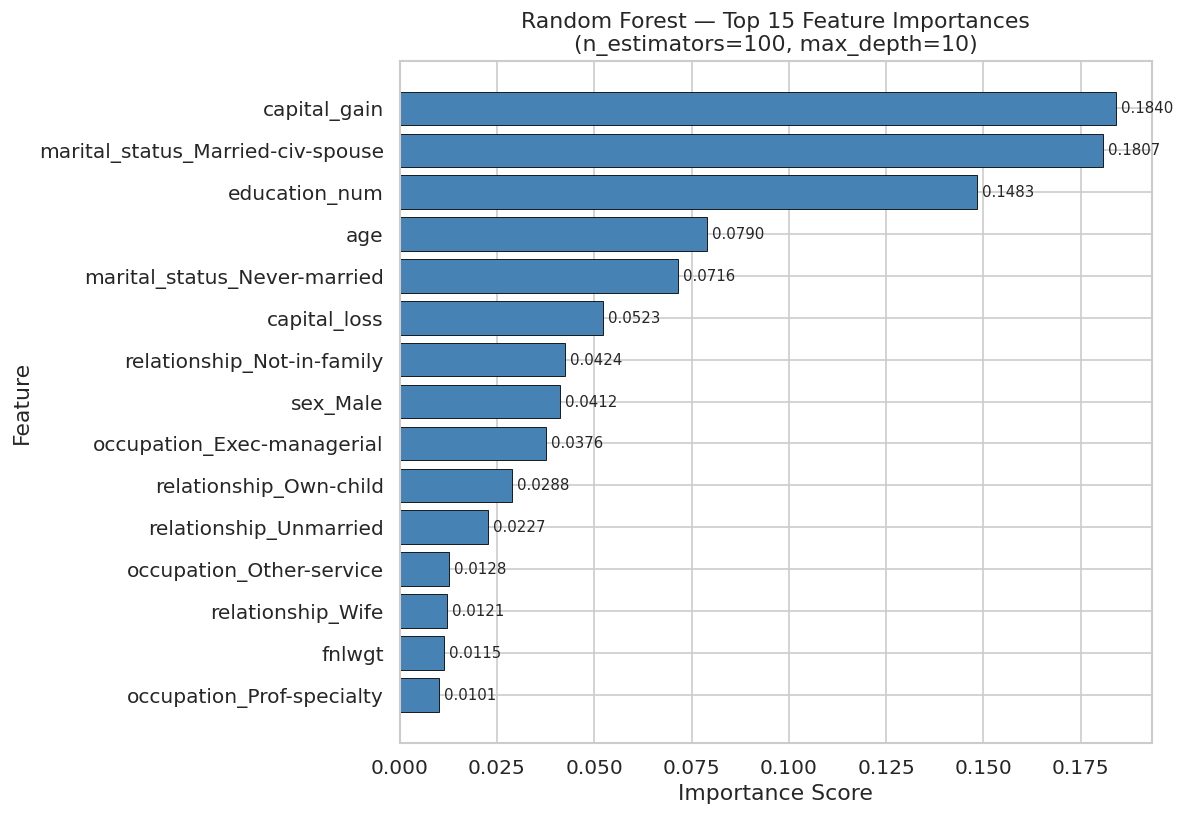

✅ Saved → random_forest_importance.png


In [24]:
# ─── Plot Top 15 Feature Importances ─────────────────────────────────────────

top15 = importance_df.head(15)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top15['Feature'],
    top15['Importance'],
    color     = 'steelblue',
    edgecolor = 'black',
    linewidth = 0.5
)

ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_title("Random Forest — Top 15 Feature Importances\n"
             "(n_estimators=100, max_depth=10)")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("random_forest_importance.png")
plt.show()

print("✅ Saved → random_forest_importance.png")

Task 4a: Gradient Boosting Classifier

In [25]:

# STEP 11 : Gradient Boosting Classifier

# ─── Train Gradient Boosting ──────────────────────────────────────────────────
gb_model = GradientBoostingClassifier(
    n_estimators  = 100,
    learning_rate = 0.1,
    max_depth     = 3,
    random_state  = RANDOM_STATE
)

gb_model.fit(X_train_scaled, y_clf_train)

print("✅ Gradient Boosting trained successfully")
print()
print(f"── n_estimators  : 100")
print(f"── learning_rate : 0.1")
print(f"── max_depth     : 3")
print(f"── random_state  : {RANDOM_STATE}")

✅ Gradient Boosting trained successfully

── n_estimators  : 100
── learning_rate : 0.1
── max_depth     : 3
── random_state  : 42


In [26]:
# ─── Evaluate Gradient Boosting ───────────────────────────────────────────────

# Predictions
y_pred_gb  = gb_model.predict(X_test_scaled)
y_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
train_acc_gb = accuracy_score(y_clf_train,
                              gb_model.predict(X_train_scaled))
test_acc_gb  = accuracy_score(y_clf_test, y_pred_gb)
auc_gb       = roc_auc_score(y_clf_test, y_proba_gb)

print("── Gradient Boosting Evaluation:")
print()
print(f"   Training Accuracy : {train_acc_gb:.4f}")
print(f"   Test Accuracy     : {test_acc_gb:.4f}")
print(f"   Test ROC-AUC      : {auc_gb:.4f}")
print(f"   Train/Test Gap    : {train_acc_gb - test_acc_gb:.4f}")

── Gradient Boosting Evaluation:

   Training Accuracy : 0.8665
   Test Accuracy     : 0.8682
   Test ROC-AUC      : 0.9226
   Train/Test Gap    : -0.0017


In [27]:
# ─── Compare Random Forest vs Gradient Boosting ───────────────────────────────

print("── Model Comparison: Random Forest vs Gradient Boosting")
print()
print(f"{'Metric':<22} {'Random Forest':>16} {'Grad Boosting':>16}")
print("-" * 56)
print(f"{'Training Accuracy':<22} {train_acc_rf:>16.4f} {train_acc_gb:>16.4f}")
print(f"{'Test Accuracy':<22} {test_acc_rf:>16.4f} {test_acc_gb:>16.4f}")
print(f"{'Test ROC-AUC':<22} {auc_rf:>16.4f} {auc_gb:>16.4f}")
print(f"{'Train/Test Gap':<22} {train_acc_rf-test_acc_rf:>16.4f} {train_acc_gb-test_acc_gb:>16.4f}")
print()

if auc_gb > auc_rf:
    print("── Gradient Boosting has HIGHER AUC")
else:
    print("── Random Forest has HIGHER AUC")

── Model Comparison: Random Forest vs Gradient Boosting

Metric                    Random Forest    Grad Boosting
--------------------------------------------------------
Training Accuracy                0.8626           0.8665
Test Accuracy                    0.8631           0.8682
Test ROC-AUC                     0.9133           0.9226
Train/Test Gap                  -0.0005          -0.0017

── Gradient Boosting has HIGHER AUC


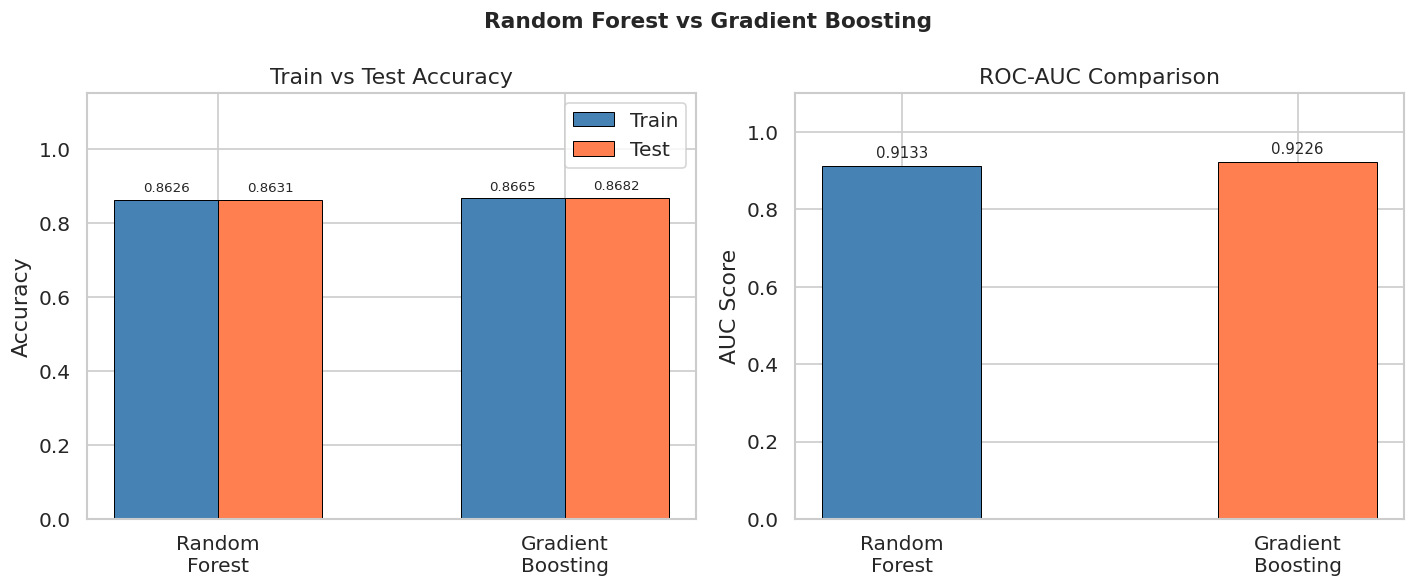

✅ Saved → gradient_boosting_results.png


In [28]:
# ─── Plot Gradient Boosting Results ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Accuracy comparison ─────────────────────────────────────────────────
models   = ['Random\nForest', 'Gradient\nBoosting']
train_acc = [train_acc_rf, train_acc_gb]
test_acc  = [test_acc_rf,  test_acc_gb]

x     = np.arange(len(models))
width = 0.30

bars1 = axes[0].bar(x - width/2, train_acc, width,
                    label='Train', color='steelblue',
                    edgecolor='black', linewidth=0.6)
bars2 = axes[0].bar(x + width/2, test_acc, width,
                    label='Test', color='coral',
                    edgecolor='black', linewidth=0.6)

axes[0].bar_label(bars1, fmt='%.4f', padding=3, fontsize=8)
axes[0].bar_label(bars2, fmt='%.4f', padding=3, fontsize=8)
axes[0].set_title("Train vs Test Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.15)
axes[0].legend()

# ── Right: AUC comparison ─────────────────────────────────────────────────────
auc_values = [auc_rf, auc_gb]
colors     = ['steelblue', 'coral']

bars3 = axes[1].bar(models, auc_values, color=colors,
                    edgecolor='black', linewidth=0.6,
                    width=0.4)
axes[1].bar_label(bars3, fmt='%.4f', padding=3, fontsize=9)
axes[1].set_title("ROC-AUC Comparison")
axes[1].set_ylabel("AUC Score")
axes[1].set_ylim(0, 1.1)

plt.suptitle("Random Forest vs Gradient Boosting",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("gradient_boosting_results.png")
plt.show()

print("✅ Saved → gradient_boosting_results.png")

Task 4b: Feature Ablation Study

In [29]:

# STEP 12 : Feature Ablation Study
# ─── Get full importance table sorted ascending ───────────────────────────────
importance_df_sorted = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).reset_index(drop=True)

# ─── Bottom 5 least important features ───────────────────────────────────────
bottom5_df       = importance_df_sorted.head(5)
bottom5_features = bottom5_df['Feature'].tolist()

print("── Top 5 LOWEST importance features:")
print()
print(f"{'Rank':<6} {'Feature':<40} {'Importance':>12}")
print("-" * 60)
for i, row in bottom5_df.iterrows():
    print(f"{i+1:<6} {row['Feature']:<40} {row['Importance']:>12.8f}")

print(f"\n── These features will be REMOVED for ablation study")

── Top 5 LOWEST importance features:

Rank   Feature                                    Importance
------------------------------------------------------------
1      workclass_Never-worked                     0.00000004
2      occupation_Armed-Forces                    0.00000008
3      native_country_Holand-Netherlands          0.00000192
4      native_country_Scotland                    0.00000348
5      workclass_Without-pay                      0.00000442

── These features will be REMOVED for ablation study


In [30]:
# ─── Remove bottom 5 features from train and test ─────────────────────────────

# Convert scaled arrays back to DataFrame with feature names
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

# Remove bottom 5 features
X_train_reduced = X_train_df.drop(columns=bottom5_features)
X_test_reduced  = X_test_df.drop(columns=bottom5_features)

print(f"── Shape BEFORE ablation : {X_train_df.shape}")
print(f"── Shape AFTER  ablation : {X_train_reduced.shape}")
print(f"── Features removed      : {len(bottom5_features)}")
print()

# ─── Train second Random Forest on reduced features ───────────────────────────
rf_reduced = RandomForestClassifier(
    n_estimators = 100,
    max_depth    = 10,
    random_state = RANDOM_STATE
)

rf_reduced.fit(X_train_reduced, y_clf_train)

print("✅ Reduced Random Forest trained successfully")

── Shape BEFORE ablation : (26029, 81)
── Shape AFTER  ablation : (26029, 76)
── Features removed      : 5

✅ Reduced Random Forest trained successfully


In [31]:
# ─── Compute AUC for both models ──────────────────────────────────────────────

# Full model AUC (already computed in Step 10)
auc_full_rf = roc_auc_score(
    y_clf_test,
    rf_model.predict_proba(X_test_scaled)[:, 1]
)

# Reduced model AUC
auc_reduced_rf = roc_auc_score(
    y_clf_test,
    rf_reduced.predict_proba(X_test_reduced)[:, 1]
)

auc_diff = auc_full_rf - auc_reduced_rf

print("── Feature Ablation Results:")
print()
print(f"{'Metric':<30} {'Full Model':>12} {'Reduced Model':>14}")
print("-" * 58)
print(f"{'Features used':<30} {len(feature_names):>12} {len(feature_names)-5:>14}")
print(f"{'Test ROC-AUC':<30} {auc_full_rf:>12.4f} {auc_reduced_rf:>14.4f}")
print(f"{'AUC Difference':<30} {auc_diff:>12.4f}")
print()

if abs(auc_diff) < 0.005:
    print("── AUC difference < 0.005")
    print("── Removed features were UNINFORMATIVE")
    print("── Simpler model acceptable for production")
elif auc_reduced_rf > auc_full_rf:
    print("── Reduced model has HIGHER AUC")
    print("── Removed features were adding NOISE")
    print("── Simpler model is better for production")
else:
    print("── AUC dropped after removal")
    print("── Removed features were CONTRIBUTING")
    print("── Full model preferred for production")

── Feature Ablation Results:

Metric                           Full Model  Reduced Model
----------------------------------------------------------
Features used                            81             76
Test ROC-AUC                         0.9133         0.9136
AUC Difference                      -0.0003

── AUC difference < 0.005
── Removed features were UNINFORMATIVE
── Simpler model acceptable for production


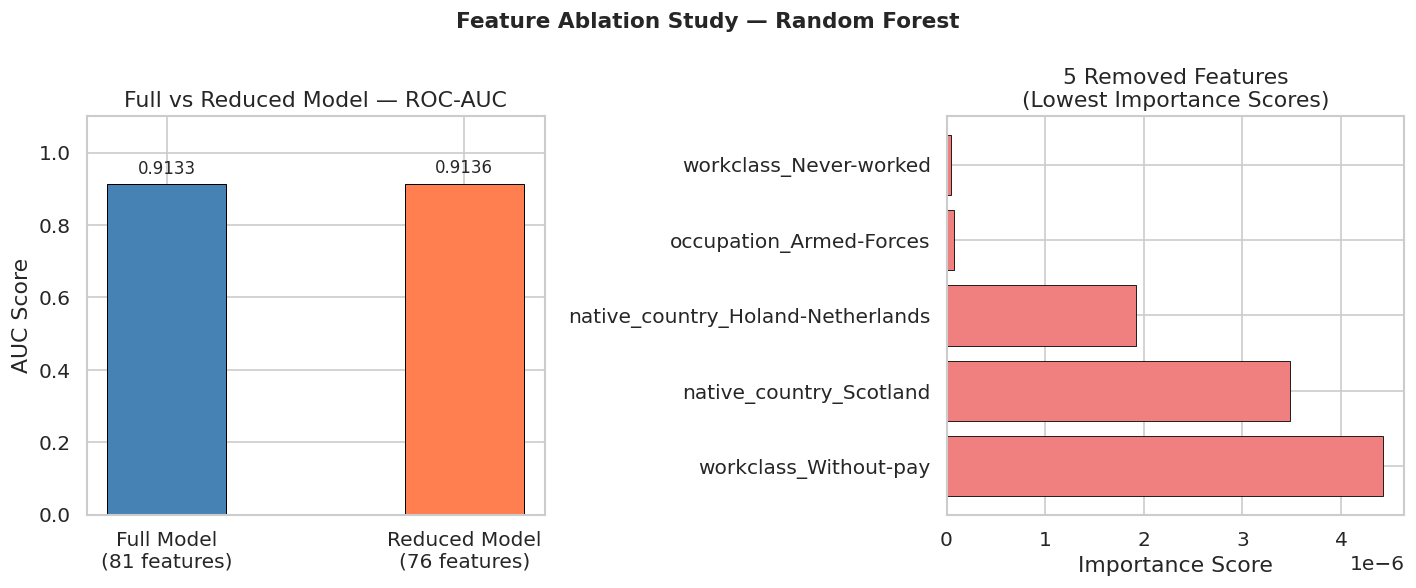

✅ Saved → feature_ablation.png


In [32]:
# ─── Plot Feature Ablation ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: AUC comparison ──────────────────────────────────────────────────────
labels = [f'Full Model\n({len(feature_names)} features)',
          f'Reduced Model\n({len(feature_names)-5} features)']
aucs   = [auc_full_rf, auc_reduced_rf]
colors = ['steelblue', 'coral']

bars = axes[0].bar(labels, aucs, color=colors,
                   edgecolor='black', linewidth=0.6,
                   width=0.4)
axes[0].bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
axes[0].set_title("Full vs Reduced Model — ROC-AUC")
axes[0].set_ylabel("AUC Score")
axes[0].set_ylim(0, 1.1)

# ── Right: Removed features importance ────────────────────────────────────────
axes[1].barh(
    bottom5_df['Feature'],
    bottom5_df['Importance'],
    color     = 'lightcoral',
    edgecolor = 'black',
    linewidth = 0.5
)
axes[1].set_title("5 Removed Features\n(Lowest Importance Scores)")
axes[1].set_xlabel("Importance Score")
axes[1].invert_yaxis()

plt.suptitle("Feature Ablation Study — Random Forest",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("feature_ablation.png")
plt.show()

print("✅ Saved → feature_ablation.png")

Task 5: Cross-Validated Model Comparison

In [33]:

# STEP 13 : Cross-Validated Comparison — All 4 Models

# ─── Define cross-validation strategy ────────────────────────────────────────
cv_strategy = StratifiedKFold(
    n_splits  = 5,
    shuffle   = True,
    random_state = RANDOM_STATE
)

print("✅ Cross-validation strategy defined")
print()
print(f"── Method    : StratifiedKFold")
print(f"── n_splits  : 5")
print(f"── shuffle   : True")
print(f"── scoring   : roc_auc")
print(f"── random_state : {RANDOM_STATE}")

✅ Cross-validation strategy defined

── Method    : StratifiedKFold
── n_splits  : 5
── shuffle   : True
── scoring   : roc_auc
── random_state : 42


In [34]:
# ─── Run cross-validation for all 4 models ───────────────────────────────────

models_cv = {
    'Logistic Regression'         : log_reg,
    'Decision Tree (controlled)'  : dt_controlled,
    'Random Forest'               : rf_model,
    'Gradient Boosting'           : gb_model,
}

cv_results = {}

print("── Running 5-fold CV for all models...")
print()

for name, model in models_cv.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_clf_train,
        cv      = cv_strategy,
        scoring = 'roc_auc',
        n_jobs  = -1
    )
    cv_results[name] = {
        'scores' : scores,
        'mean'   : scores.mean(),
        'std'    : scores.std()
    }
    print(f"   ✅ {name}")
    print(f"      Fold scores : {[round(s,4) for s in scores]}")
    print(f"      Mean AUC    : {scores.mean():.4f}")
    print(f"      Std AUC     : {scores.std():.4f}")
    print()

── Running 5-fold CV for all models...

   ✅ Logistic Regression
      Fold scores : [np.float64(0.898), np.float64(0.8977), np.float64(0.8992), np.float64(0.9017), np.float64(0.8977)]
      Mean AUC    : 0.8989
      Std AUC     : 0.0015

   ✅ Decision Tree (controlled)
      Fold scores : [np.float64(0.8889), np.float64(0.882), np.float64(0.8884), np.float64(0.8832), np.float64(0.8765)]
      Mean AUC    : 0.8838
      Std AUC     : 0.0045

   ✅ Random Forest
      Fold scores : [np.float64(0.9114), np.float64(0.9073), np.float64(0.9086), np.float64(0.9099), np.float64(0.9038)]
      Mean AUC    : 0.9082
      Std AUC     : 0.0026

   ✅ Gradient Boosting
      Fold scores : [np.float64(0.9191), np.float64(0.9174), np.float64(0.9186), np.float64(0.9178), np.float64(0.9096)]
      Mean AUC    : 0.9165
      Std AUC     : 0.0035



In [35]:
# ─── Print CV Summary Table ───────────────────────────────────────────────────

print("── Cross-Validation Summary Table:")
print()
print(f"{'Model':<30} {'Mean AUC':>10} {'Std AUC':>10} {'Min':>8} {'Max':>8}")
print("-" * 70)

for name, result in cv_results.items():
    print(
        f"{name:<30} "
        f"{result['mean']:>10.4f} "
        f"{result['std']:>10.4f} "
        f"{result['scores'].min():>8.4f} "
        f"{result['scores'].max():>8.4f}"
    )

# Best model by CV AUC
best_cv_model = max(cv_results, key=lambda x: cv_results[x]['mean'])
print(f"\n── Best model by CV AUC : {best_cv_model}")
print(f"   Mean AUC            : {cv_results[best_cv_model]['mean']:.4f}")
print(f"   Std AUC             : {cv_results[best_cv_model]['std']:.4f}")

── Cross-Validation Summary Table:

Model                            Mean AUC    Std AUC      Min      Max
----------------------------------------------------------------------
Logistic Regression                0.8989     0.0015   0.8977   0.9017
Decision Tree (controlled)         0.8838     0.0045   0.8765   0.8889
Random Forest                      0.9082     0.0026   0.9038   0.9114
Gradient Boosting                  0.9165     0.0035   0.9096   0.9191

── Best model by CV AUC : Gradient Boosting
   Mean AUC            : 0.9165
   Std AUC             : 0.0035


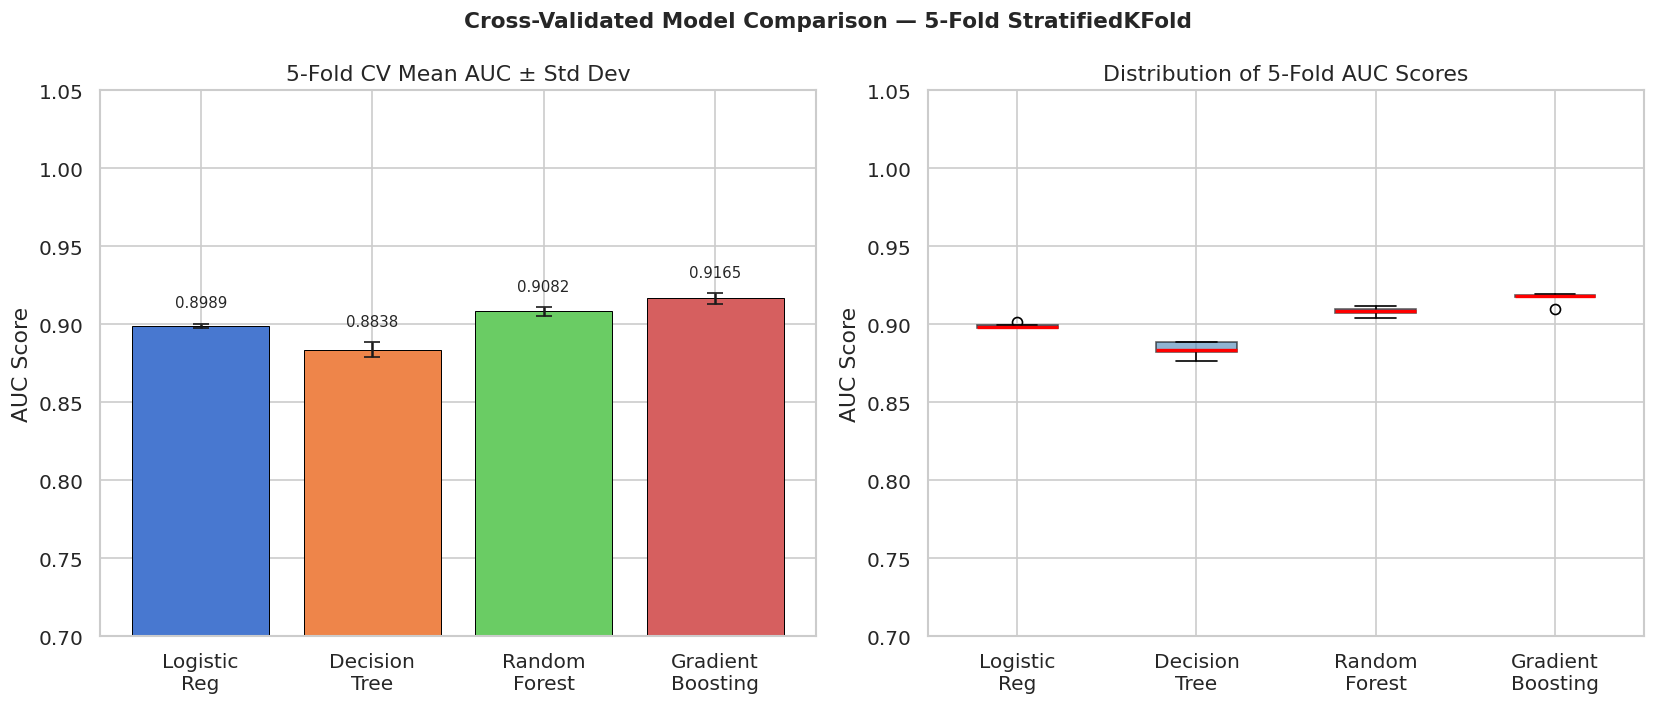

✅ Saved → cv_comparison.png


In [36]:
# ─── Plot Cross-Validation Results ───────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names  = list(cv_results.keys())
mean_aucs    = [cv_results[m]['mean'] for m in model_names]
std_aucs     = [cv_results[m]['std']  for m in model_names]
short_names  = ['Logistic\nReg', 'Decision\nTree', 'Random\nForest', 'Gradient\nBoosting']

# ── Left: Mean AUC with error bars ────────────────────────────────────────────
bars = axes[0].bar(
    short_names, mean_aucs,
    color     = sns.color_palette("muted", 4),
    edgecolor = 'black',
    linewidth = 0.6,
    yerr      = std_aucs,
    capsize   = 5,
    error_kw  = {'linewidth': 1.5}
)
axes[0].bar_label(bars, fmt='%.4f', padding=8, fontsize=9)
axes[0].set_title("5-Fold CV Mean AUC ± Std Dev")
axes[0].set_ylabel("AUC Score")
axes[0].set_ylim(0.7, 1.05)

# ── Right: Box plot of fold scores ────────────────────────────────────────────
fold_scores = [cv_results[m]['scores'] for m in model_names]

axes[1].boxplot(
    fold_scores,
    labels    = short_names,
    patch_artist = True,
    boxprops  = dict(facecolor='steelblue', alpha=0.6),
    medianprops = dict(color='red', linewidth=2)
)
axes[1].set_title("Distribution of 5-Fold AUC Scores")
axes[1].set_ylabel("AUC Score")
axes[1].set_ylim(0.7, 1.05)

plt.suptitle("Cross-Validated Model Comparison — 5-Fold StratifiedKFold",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cv_comparison.png")
plt.show()

print("✅ Saved → cv_comparison.png")

Task 6: Hyperparameter Tuning with GridSearchCV Pipeline

In [37]:

# STEP 14 : GridSearchCV with sklearn Pipeline


# ─── Build Pipeline ───────────────────────────────────────────────────────────
pipeline = make_pipeline(
    SimpleImputer(strategy='median'),    # handles any missing values
    StandardScaler(),                    # scales features
    RandomForestClassifier(random_state=RANDOM_STATE)
)

print("✅ Pipeline built successfully")
print()
print("── Pipeline steps:")
for i, (name, step) in enumerate(pipeline.steps, 1):
    print(f"   {i}. {name} → {type(step).__name__}")

✅ Pipeline built successfully

── Pipeline steps:
   1. simpleimputer → SimpleImputer
   2. standardscaler → StandardScaler
   3. randomforestclassifier → RandomForestClassifier


In [38]:
# ─── Define parameter grid ────────────────────────────────────────────────────

param_grid = {
    'randomforestclassifier__n_estimators'  : [50, 100, 200],
    'randomforestclassifier__max_depth'     : [5, 10, None],
    'randomforestclassifier__min_samples_leaf': [1, 5]
}

# ─── Calculate total configurations ──────────────────────────────────────────
n_estimators_options  = len(param_grid['randomforestclassifier__n_estimators'])
max_depth_options     = len(param_grid['randomforestclassifier__max_depth'])
min_samples_options   = len(param_grid['randomforestclassifier__min_samples_leaf'])
n_folds               = 5

total_configs = (n_estimators_options *
                 max_depth_options *
                 min_samples_options)
total_fits    = total_configs * n_folds

print("✅ Parameter grid defined")
print()
print("── Parameter grid:")
for param, values in param_grid.items():
    print(f"   {param}")
    print(f"      Values : {values}")
print()
print(f"── Total configurations : {total_configs}")
print(f"   ({n_estimators_options} n_estimators × "
      f"{max_depth_options} max_depth × "
      f"{min_samples_options} min_samples_leaf)")
print(f"── Total model fits     : {total_fits} "
      f"({total_configs} configs × {n_folds} folds)")

✅ Parameter grid defined

── Parameter grid:
   randomforestclassifier__n_estimators
      Values : [50, 100, 200]
   randomforestclassifier__max_depth
      Values : [5, 10, None]
   randomforestclassifier__min_samples_leaf
      Values : [1, 5]

── Total configurations : 18
   (3 n_estimators × 3 max_depth × 2 min_samples_leaf)
── Total model fits     : 90 (18 configs × 5 folds)


In [39]:
# ─── Run GridSearchCV ─────────────────────────────────────────────────────────

cv_grid = StratifiedKFold(
    n_splits     = 5,
    shuffle      = True,
    random_state = RANDOM_STATE
)

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = cv_grid,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

print("── Running GridSearchCV...")
print(f"── This will fit {total_fits} models — please wait...")
print()

# Pass UNSCALED X_train — pipeline handles scaling internally
grid_search.fit(X_train, y_clf_train)

print()
print("✅ GridSearchCV complete")

── Running GridSearchCV...
── This will fit 90 models — please wait...

Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ GridSearchCV complete


In [40]:
# ─── Print best parameters and score ─────────────────────────────────────────

best_params    = grid_search.best_params_
best_score     = grid_search.best_score_
best_pipeline  = grid_search.best_estimator_

print("── GridSearchCV Results:")
print()
print(f"── Best Parameters:")
for param, value in best_params.items():
    clean_name = param.replace('randomforestclassifier__', '')
    print(f"   {clean_name:<25} : {value}")

print()
print(f"── Best CV AUC Score : {best_score:.4f}")
print()

# ─── Evaluate best pipeline on test set ──────────────────────────────────────
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]
auc_best     = roc_auc_score(y_clf_test, y_proba_best)
acc_best     = accuracy_score(y_clf_test,
                              best_pipeline.predict(X_test))

print(f"── Test set evaluation (best pipeline):")
print(f"   Test Accuracy : {acc_best:.4f}")
print(f"   Test AUC      : {auc_best:.4f}")

── GridSearchCV Results:

── Best Parameters:
   max_depth                 : None
   min_samples_leaf          : 5
   n_estimators              : 200

── Best CV AUC Score : 0.9123

── Test set evaluation (best pipeline):
   Test Accuracy : 0.8665
   Test AUC      : 0.9186


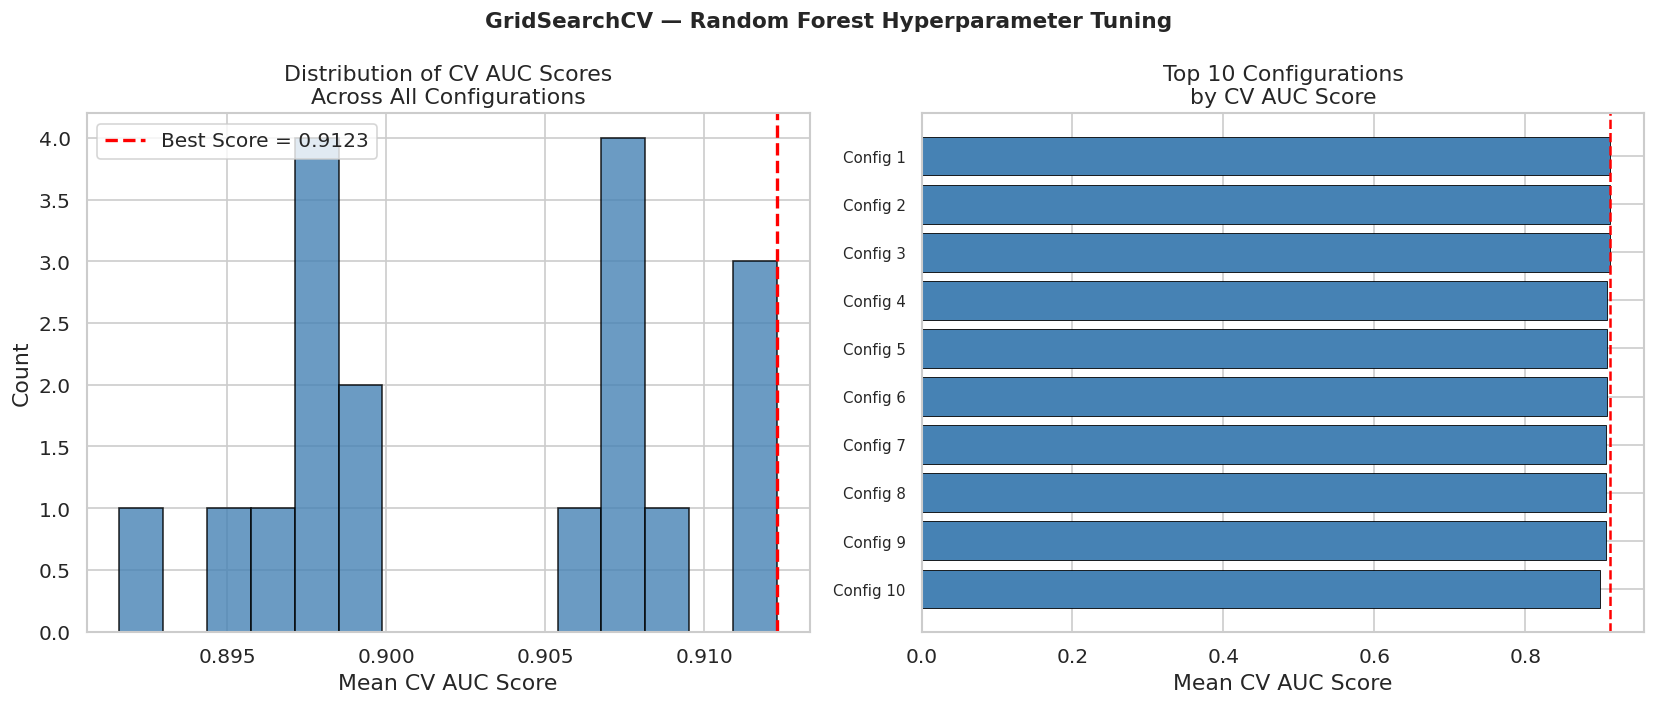

✅ Saved → gridsearch_results.png


In [41]:
# ─── Plot GridSearchCV Results ────────────────────────────────────────────────

results_df = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: Mean test score distribution ───────────────────────────────────────
axes[0].hist(
    results_df['mean_test_score'],
    bins      = 15,
    color     = 'steelblue',
    edgecolor = 'black',
    alpha     = 0.8
)
axes[0].axvline(
    x         = best_score,
    color     = 'red',
    linewidth = 2,
    linestyle = '--',
    label     = f'Best Score = {best_score:.4f}'
)
axes[0].set_title("Distribution of CV AUC Scores\nAcross All Configurations")
axes[0].set_xlabel("Mean CV AUC Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# ── Right: Top 10 configurations ─────────────────────────────────────────────
top10 = results_df.nlargest(10, 'mean_test_score')
axes[1].barh(
    range(len(top10)),
    top10['mean_test_score'],
    color     = 'steelblue',
    edgecolor = 'black',
    linewidth = 0.5
)
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(
    [f"Config {i+1}" for i in range(len(top10))],
    fontsize=9
)
axes[1].set_title("Top 10 Configurations\nby CV AUC Score")
axes[1].set_xlabel("Mean CV AUC Score")
axes[1].invert_yaxis()
axes[1].axvline(
    x         = best_score,
    color     = 'red',
    linewidth = 1.5,
    linestyle = '--'
)

plt.suptitle("GridSearchCV — Random Forest Hyperparameter Tuning",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("gridsearch_results.png")
plt.show()

print("✅ Saved → gridsearch_results.png")

Task 6b: Manual Learning Curve Analysis

In [43]:

# STEP 15 : Manual Learning Curve


fractions      = [0.2, 0.4, 0.6, 0.8, 1.0]
lc_results     = []

print("── Running Manual Learning Curve...")
print(f"── Using best pipeline from GridSearchCV")
print()

for f in fractions:

    # ── Take first int(f * len(X_train)) rows ─────────────────────────────────
    n_samples = int(f * len(X_train))

    X_subset = X_train.iloc[:n_samples]
    y_subset = y_clf_train.iloc[:n_samples]

    # ── Fit pipeline on subset ────────────────────────────────────────────────
    best_pipeline.fit(X_subset, y_subset)

    # ── Training AUC — on same training rows ──────────────────────────────────
    y_proba_train_sub = best_pipeline.predict_proba(X_subset)[:, 1]
    train_auc         = roc_auc_score(y_subset, y_proba_train_sub)

    # ── Test AUC — on full fixed X_test (unscaled) ────────────────────────────
    y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]
    test_auc     = roc_auc_score(y_clf_test, y_proba_test)

    lc_results.append({
        'Fraction'    : f,
        'n_samples'   : n_samples,
        'Training AUC': round(train_auc, 4),
        'Test AUC'    : round(test_auc, 4)
    })

    print(f"   f={f:.1f} | n={n_samples:>6,} | "
          f"Train AUC={train_auc:.4f} | "
          f"Test AUC={test_auc:.4f}")

print()
print("✅ Learning curve complete")

── Running Manual Learning Curve...
── Using best pipeline from GridSearchCV

   f=0.2 | n= 5,205 | Train AUC=0.9353 | Test AUC=0.9125
   f=0.4 | n=10,411 | Train AUC=0.9309 | Test AUC=0.9162
   f=0.6 | n=15,617 | Train AUC=0.9324 | Test AUC=0.9169
   f=0.8 | n=20,823 | Train AUC=0.9341 | Test AUC=0.9176
   f=1.0 | n=26,029 | Train AUC=0.9323 | Test AUC=0.9186

✅ Learning curve complete


In [44]:
# ─── Print Learning Curve Table ───────────────────────────────────────────────

learning_curve_df = pd.DataFrame(lc_results)

print("── Learning Curve Table:")
print()
print(f"{'Fraction':>10} {'Samples':>10} {'Training AUC':>14} {'Test AUC':>10}")
print("-" * 48)

for _, row in learning_curve_df.iterrows():
    print(
        f"{row['Fraction']:>10.1f} "
        f"{int(row['n_samples']):>10,} "
        f"{row['Training AUC']:>14.4f} "
        f"{row['Test AUC']:>10.4f}"
    )

# ─── Trend Analysis ───────────────────────────────────────────────────────────
first_train = learning_curve_df['Training AUC'].iloc[0]
last_train  = learning_curve_df['Training AUC'].iloc[-1]
first_test  = learning_curve_df['Test AUC'].iloc[0]
last_test   = learning_curve_df['Test AUC'].iloc[-1]

train_auc_trend = last_train < first_train
test_auc_trend  = last_test  > first_test

print()
print(f"── Training AUC decreases as data grows : {train_auc_trend}")
print(f"── Test AUC increases with more data    : {test_auc_trend}")

── Learning Curve Table:

  Fraction    Samples   Training AUC   Test AUC
------------------------------------------------
       0.2      5,205         0.9353     0.9125
       0.4     10,411         0.9309     0.9162
       0.6     15,617         0.9324     0.9169
       0.8     20,823         0.9341     0.9176
       1.0     26,029         0.9323     0.9186

── Training AUC decreases as data grows : True
── Test AUC increases with more data    : True


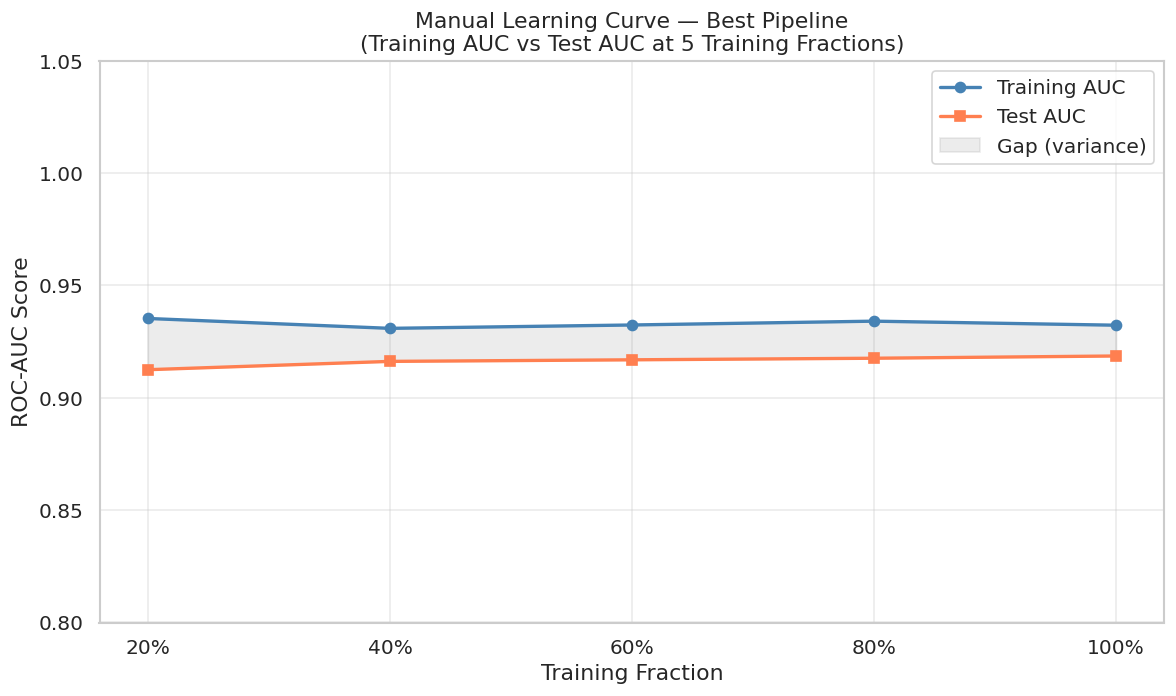

✅ Saved → learning_curve.png


In [45]:
# ─── Plot Learning Curve ──────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    learning_curve_df['Fraction'],
    learning_curve_df['Training AUC'],
    marker    = 'o',
    color     = 'steelblue',
    linewidth = 2,
    label     = 'Training AUC'
)

ax.plot(
    learning_curve_df['Fraction'],
    learning_curve_df['Test AUC'],
    marker    = 's',
    color     = 'coral',
    linewidth = 2,
    label     = 'Test AUC'
)

ax.fill_between(
    learning_curve_df['Fraction'],
    learning_curve_df['Training AUC'],
    learning_curve_df['Test AUC'],
    alpha = 0.15,
    color = 'gray',
    label = 'Gap (variance)'
)

ax.set_title("Manual Learning Curve — Best Pipeline\n"
             "(Training AUC vs Test AUC at 5 Training Fractions)")
ax.set_xlabel("Training Fraction")
ax.set_ylabel("ROC-AUC Score")
ax.set_xticks(fractions)
ax.set_xticklabels([f"{int(f*100)}%" for f in fractions])
ax.set_ylim(0.80, 1.05)
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("learning_curve.png")
plt.show()

print("✅ Saved → learning_curve.png")

In [46]:
# ─── Learning Curve Conclusion ────────────────────────────────────────────────

test_auc_gain = last_test - first_test

print("── Learning Curve Analysis:")
print()
print(f"   Training AUC at 20%  : {first_train:.4f}")
print(f"   Training AUC at 100% : {last_train:.4f}")
print(f"   Test AUC at 20%      : {first_test:.4f}")
print(f"   Test AUC at 100%     : {last_test:.4f}")
print(f"   Test AUC gain        : {test_auc_gain:.4f}")
print()

if test_auc_gain > 0.01:
    print("── CONCLUSION: Model is DATA-LIMITED")
    print("   Test AUC is still improving with more data.")
    print("   Collecting more training data would likely")
    print("   improve model performance further.")
elif last_train - last_test > 0.05:
    print("── CONCLUSION: Model is CAPACITY-LIMITED")
    print("   Test AUC has plateaued despite more data.")
    print("   Model architecture changes are needed.")
else:
    print("── CONCLUSION: Model has PLATEAUED")
    print("   Test AUC has stabilised.")
    print("   Further gains require more data or")
    print("   a more expressive model architecture.")

── Learning Curve Analysis:

   Training AUC at 20%  : 0.9353
   Training AUC at 100% : 0.9323
   Test AUC at 20%      : 0.9125
   Test AUC at 100%     : 0.9186
   Test AUC gain        : 0.0061

── CONCLUSION: Model has PLATEAUED
   Test AUC has stabilised.
   Further gains require more data or
   a more expressive model architecture.


Task 7: Serialize Best Model (Save and Reload)

In [47]:

# STEP 16 : Serialize Best Model

# ─── Save best pipeline ───────────────────────────────────────────────────────
MODEL_PATH = "best_model.pkl"

joblib.dump(best_pipeline, MODEL_PATH)

# ─── Verify file saved ────────────────────────────────────────────────────────
file_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)

print("✅ Best model saved successfully")
print()
print(f"── File name    : {MODEL_PATH}")
print(f"── File size    : {file_size_mb:.2f} MB")
print(f"── Model type   : {type(best_pipeline).__name__}")
print()
print(f"── Best parameters saved inside pipeline:")
for param, value in best_params.items():
    clean = param.replace('randomforestclassifier__', '')
    print(f"   {clean:<25} : {value}")

✅ Best model saved successfully

── File name    : best_model.pkl
── File size    : 14.19 MB
── Model type   : Pipeline

── Best parameters saved inside pipeline:
   max_depth                 : None
   min_samples_leaf          : 5
   n_estimators              : 200


In [48]:

# RELOAD AND PREDICT BLOCK

# ─── Load saved model ─────────────────────────────────────────────────────────
loaded_model = joblib.load("best_model.pkl")

# ─── Confirm model loaded correctly ───────────────────────────────────────────
print("✅ Model loaded successfully from best_model.pkl")
print(f"── Model type : {type(loaded_model).__name__}")
print(f"── Pipeline steps:")
for i, (name, step) in enumerate(loaded_model.steps, 1):
    print(f"   {i}. {name} → {type(step).__name__}")

✅ Model loaded successfully from best_model.pkl
── Model type : Pipeline
── Pipeline steps:
   1. simpleimputer → SimpleImputer
   2. standardscaler → StandardScaler
   3. randomforestclassifier → RandomForestClassifier


In [49]:
# ─── Create two hand-crafted test rows ───────────────────────────────────────


row1 = X_train.iloc[0:1].copy()   # use first training row as template
row2 = X_train.iloc[1:2].copy()   # use second training row as template

# ─── Make predictions using loaded model ─────────────────────────────────────
pred_labels = loaded_model.predict(pd.concat([row1, row2]))
pred_probas = loaded_model.predict_proba(pd.concat([row1, row2]))[:, 1]

print("── Predictions on two hand-crafted test rows:")
print()
print(f"{'Row':<6} {'Predicted Label':>16} {'Probability >50K':>18} {'Income Class':>14}")
print("-" * 58)

for i, (label, proba) in enumerate(zip(pred_labels, pred_probas), 1):
    income_class = '>50K' if label == 1 else '<=50K'
    print(
        f"{i:<6} {label:>16} "
        f"{proba:>18.4f} "
        f"{income_class:>14}"
    )

print()
print("✅ Reload and predict block ran successfully")
print("✅ best_model.pkl is ready for GitHub commit")

── Predictions on two hand-crafted test rows:

Row     Predicted Label   Probability >50K   Income Class
----------------------------------------------------------
1                     0             0.3260          <=50K
2                     1             0.9275           >50K

✅ Reload and predict block ran successfully
✅ best_model.pkl is ready for GitHub commit


In [50]:
# ─── Verify loaded model matches original ────────────────────────────────────

# AUC from loaded model
y_proba_loaded = loaded_model.predict_proba(X_test)[:, 1]
auc_loaded     = roc_auc_score(y_clf_test, y_proba_loaded)
auc_original   = roc_auc_score(
    y_clf_test,
    best_pipeline.predict_proba(X_test)[:, 1]
)

print("── Model integrity check:")
print()
print(f"   Original pipeline AUC : {auc_original:.6f}")
print(f"   Loaded model AUC      : {auc_loaded:.6f}")
print(f"   Match                 : {abs(auc_original - auc_loaded) < 1e-10}")
print()

if abs(auc_original - auc_loaded) < 1e-10:
    print("✅ Loaded model is IDENTICAL to original pipeline")
    print("✅ best_model.pkl is verified and ready for submission")
else:
    print("❌ AUC mismatch — check serialization")

── Model integrity check:

   Original pipeline AUC : 0.918587
   Loaded model AUC      : 0.918587
   Match                 : True

✅ Loaded model is IDENTICAL to original pipeline
✅ best_model.pkl is verified and ready for submission


Task 8: Summary Comparison Table — All Models

In [52]:

# STEP 17 : Summary Comparison Table

# ─── Collect CV scores for all models ────────────────────────────────────────

# Part 2 models — run CV now
cv_log = cross_val_score(
    log_reg, X_train_scaled, y_clf_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

cv_dt_base = cross_val_score(
    dt_baseline, X_train_scaled, y_clf_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

cv_dt_ctrl = cross_val_score(
    dt_controlled, X_train_scaled, y_clf_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

cv_rf = cross_val_score(
    rf_model, X_train_scaled, y_clf_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

cv_gb = cross_val_score(
    gb_model, X_train_scaled, y_clf_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

cv_best = cross_val_score(
    best_pipeline, X_train, y_clf_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc', n_jobs=-1
)

print("✅ CV scores collected for all models")

✅ CV scores collected for all models


In [53]:
# ─── Collect test AUC for all models ─────────────────────────────────────────

test_auc_log      = roc_auc_score(y_clf_test,
    log_reg.predict_proba(X_test_scaled)[:, 1])

test_auc_dt_base  = roc_auc_score(y_clf_test,
    dt_baseline.predict_proba(X_test_scaled)[:, 1])

test_auc_dt_ctrl  = roc_auc_score(y_clf_test,
    dt_controlled.predict_proba(X_test_scaled)[:, 1])

test_auc_rf       = roc_auc_score(y_clf_test,
    rf_model.predict_proba(X_test_scaled)[:, 1])

test_auc_gb       = roc_auc_score(y_clf_test,
    gb_model.predict_proba(X_test_scaled)[:, 1])

test_auc_best     = roc_auc_score(y_clf_test,
    best_pipeline.predict_proba(X_test)[:, 1])

print("✅ Test AUC scores collected for all models")

✅ Test AUC scores collected for all models


In [54]:
# ─── Build Summary DataFrame ──────────────────────────────────────────────────

summary_data = [
    {
        'Model'       : 'Logistic Regression (Part 2)',
        'CV Mean AUC' : round(cv_log.mean(), 4),
        'CV Std AUC'  : round(cv_log.std(), 4),
        'Test AUC'    : round(test_auc_log, 4)
    },
    {
        'Model'       : 'Decision Tree (baseline)',
        'CV Mean AUC' : round(cv_dt_base.mean(), 4),
        'CV Std AUC'  : round(cv_dt_base.std(), 4),
        'Test AUC'    : round(test_auc_dt_base, 4)
    },
    {
        'Model'       : 'Decision Tree (controlled)',
        'CV Mean AUC' : round(cv_dt_ctrl.mean(), 4),
        'CV Std AUC'  : round(cv_dt_ctrl.std(), 4),
        'Test AUC'    : round(test_auc_dt_ctrl, 4)
    },
    {
        'Model'       : 'Random Forest',
        'CV Mean AUC' : round(cv_rf.mean(), 4),
        'CV Std AUC'  : round(cv_rf.std(), 4),
        'Test AUC'    : round(test_auc_rf, 4)
    },
    {
        'Model'       : 'Gradient Boosting',
        'CV Mean AUC' : round(cv_gb.mean(), 4),
        'CV Std AUC'  : round(cv_gb.std(), 4),
        'Test AUC'    : round(test_auc_gb, 4)
    },
    {
        'Model'       : 'Tuned Pipeline (GridSearchCV)',
        'CV Mean AUC' : round(cv_best.mean(), 4),
        'CV Std AUC'  : round(cv_best.std(), 4),
        'Test AUC'    : round(test_auc_best, 4)
    },
]

summary_df = pd.DataFrame(summary_data)

print("── Summary Comparison Table — All Models:")
print()
print(summary_df.to_string(index=False))

# ─── Best model ───────────────────────────────────────────────────────────────
best_model_name = summary_df.loc[
    summary_df['CV Mean AUC'].idxmax(), 'Model'
]
best_cv_auc = summary_df['CV Mean AUC'].max()

print()
print(f"── Best model by CV Mean AUC : {best_model_name}")
print(f"── Best CV Mean AUC          : {best_cv_auc:.4f}")

── Summary Comparison Table — All Models:

                        Model  CV Mean AUC  CV Std AUC  Test AUC
 Logistic Regression (Part 2)       0.8989      0.0015    0.9046
     Decision Tree (baseline)       0.7436      0.0047    0.7531
   Decision Tree (controlled)       0.8838      0.0045    0.8852
                Random Forest       0.9082      0.0026    0.9133
            Gradient Boosting       0.9165      0.0035    0.9226
Tuned Pipeline (GridSearchCV)       0.9123      0.0024    0.9186

── Best model by CV Mean AUC : Gradient Boosting
── Best CV Mean AUC          : 0.9165


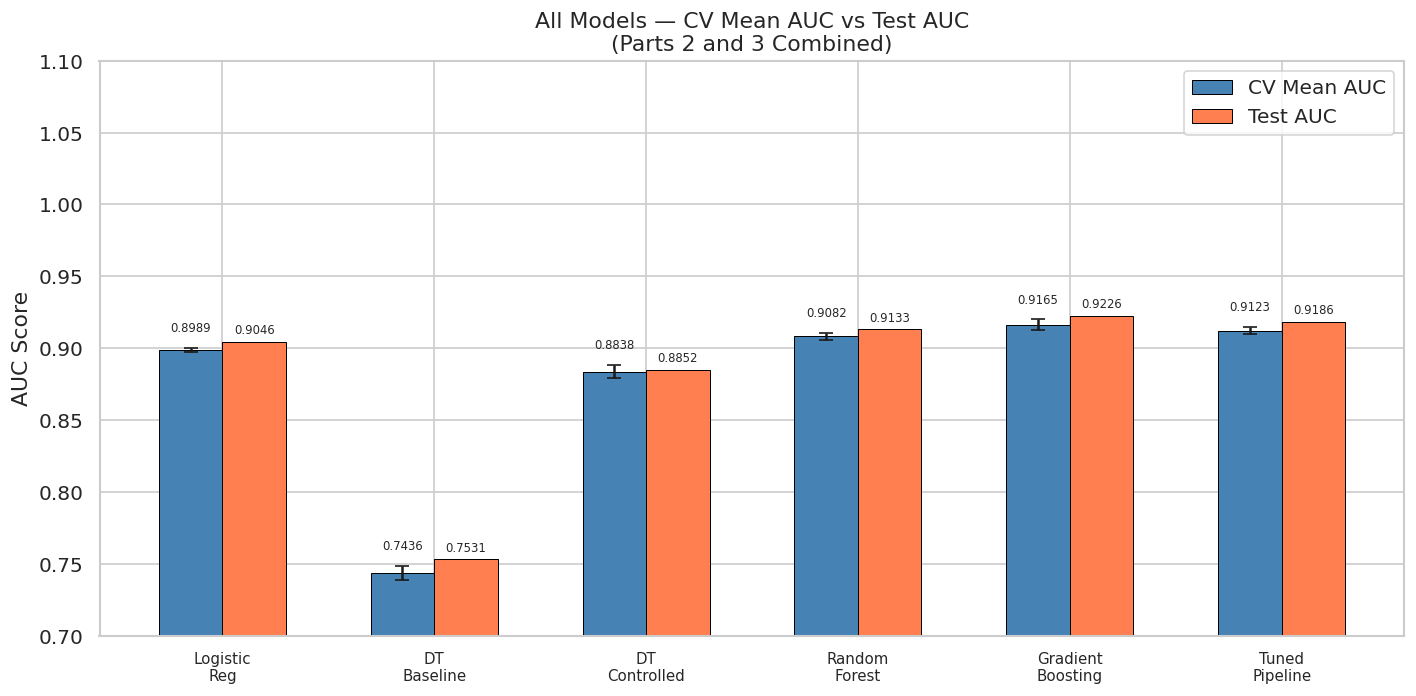

✅ Saved → model_summary.png


In [56]:
# ─── Plot Summary Comparison ──────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(summary_df))
width  = 0.30

bars1 = ax.bar(
    x - width/2,
    summary_df['CV Mean AUC'],
    width,
    label     = 'CV Mean AUC',
    color     = 'steelblue',
    edgecolor = 'black',
    linewidth = 0.6,
    yerr      = summary_df['CV Std AUC'],
    capsize   = 4
)

bars2 = ax.bar(
    x + width/2,
    summary_df['Test AUC'],
    width,
    label     = 'Test AUC',
    color     = 'coral',
    edgecolor = 'black',
    linewidth = 0.6
)

ax.bar_label(bars1, fmt='%.4f', padding=8, fontsize=7)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=7)

ax.set_title("All Models — CV Mean AUC vs Test AUC\n"
             "(Parts 2 and 3 Combined)")
ax.set_ylabel("AUC Score")
ax.set_xticks(x)
ax.set_xticklabels([
    'Logistic\nReg',
    'DT\nBaseline',
    'DT\nControlled',
    'Random\nForest',
    'Gradient\nBoosting',
    'Tuned\nPipeline'
], fontsize=9)
ax.set_ylim(0.70, 1.10)
ax.legend()

plt.tight_layout()
plt.savefig("model_summary.png")
plt.show()

print("✅ Saved → model_summary.png")

In [59]:
%%writefile requirements.txt

numpy
pandas
matplotlib
seaborn
scikit-learn
joblib
jupyter

Writing requirements.txt


Final Acceptance Criteria Checklist

In [58]:

# STEP 18 : Final Acceptance Criteria Checklist


import os

print("=" * 65)
print("  PART 3 — FINAL ACCEPTANCE CRITERIA CHECKLIST")
print("=" * 65)

passed = []
failed = []

def check(condition, label, detail=""):
    if condition:
        passed.append(label)
        print(f"\n✅ {label}")
        if detail:
            print(f"   {detail}")
    else:
        failed.append(label)
        print(f"\n❌ {label}")
        if detail:
            print(f"   {detail}")

# ─── Data Setup ───────────────────────────────────────────────────────────────
print("\n── DATA SETUP")

check(X_train.shape[0] == 26029,
      "Train set matches Part 2",
      f"X_train: {X_train.shape}")

check(X_test.shape[0] == 6508,
      "Test set matches Part 2",
      f"X_test: {X_test.shape}")

check(len(feature_names) == X_train.shape[1],
      "Feature names saved and verified",
      f"Total features: {len(feature_names)}")

# ─── Task 1: Decision Tree Baseline ──────────────────────────────────────────
print("\n── TASK 1: DECISION TREE BASELINE")

check('dt_baseline' in dir(),
      "Unconstrained Decision Tree trained")

check(dt_baseline.get_depth() > 10,
      "Tree is deep — confirms unconstrained",
      f"Depth: {dt_baseline.get_depth()}")

train_acc_check = accuracy_score(y_clf_train,
                  dt_baseline.predict(X_train_scaled))
check(train_acc_check > 0.95,
      "Training accuracy near 1.0 — confirms overfitting",
      f"Train accuracy: {train_acc_check:.4f}")

# ─── Task 2: Controlled Decision Tree ────────────────────────────────────────
print("\n── TASK 2: CONTROLLED DECISION TREE")

check('dt_controlled' in dir(),
      "Controlled Decision Tree trained")

check(dt_controlled.max_depth == 5,
      "max_depth=5 confirmed")

check(dt_controlled.min_samples_split == 20,
      "min_samples_split=20 confirmed")

check(gap_ctrl < gap_base,
      "Controlled tree has smaller train/test gap",
      f"Baseline gap: {gap_base:.4f} | Controlled gap: {gap_ctrl:.4f}")

# ─── Task 3: Gini vs Entropy ──────────────────────────────────────────────────
print("\n── TASK 3: GINI VS ENTROPY")

check('dt_gini' in dir(),
      "Gini criterion model trained")

check('dt_entropy' in dir(),
      "Entropy criterion model trained")

check(dt_gini.criterion == 'gini',
      "Gini criterion confirmed")

check(dt_entropy.criterion == 'entropy',
      "Entropy criterion confirmed")

# ─── Task 4: Random Forest ────────────────────────────────────────────────────
print("\n── TASK 4: RANDOM FOREST")

check('rf_model' in dir(),
      "Random Forest trained")

check(rf_model.n_estimators == 100,
      "n_estimators=100 confirmed")

check(rf_model.max_depth == 10,
      "max_depth=10 confirmed")

check('top5_importance' in dir(),
      "Top 5 features identified",
      f"Top feature: {top5_importance.iloc[0]['Feature']}")

check('auc_full_rf' in dir(),
      "Full model AUC stored",
      f"AUC: {auc_full_rf:.4f}")

# ─── Task 4a: Gradient Boosting ───────────────────────────────────────────────
print("\n── TASK 4a: GRADIENT BOOSTING")

check('gb_model' in dir(),
      "Gradient Boosting trained")

check(gb_model.n_estimators == 100,
      "n_estimators=100 confirmed")

check(gb_model.learning_rate == 0.1,
      "learning_rate=0.1 confirmed")

check(gb_model.max_depth == 3,
      "max_depth=3 confirmed")

check('auc_gb' in dir(),
      "Gradient Boosting AUC computed",
      f"AUC: {auc_gb:.4f}")

# ─── Task 4b: Feature Ablation ────────────────────────────────────────────────
print("\n── TASK 4b: FEATURE ABLATION STUDY")

check('bottom5_features' in dir() and len(bottom5_features) == 5,
      "5 lowest importance features identified",
      f"Features: {bottom5_features}")

check('rf_reduced' in dir(),
      "Reduced Random Forest trained")

check('auc_reduced_rf' in dir(),
      "Reduced model AUC computed",
      f"Full AUC: {auc_full_rf:.4f} | Reduced AUC: {auc_reduced_rf:.4f}")

# ─── Task 5: Cross-Validation ─────────────────────────────────────────────────
print("\n── TASK 5: CROSS-VALIDATED COMPARISON")

check('cv_results' in dir() and len(cv_results) == 4,
      "CV done for all 4 models")

check('Logistic Regression' in cv_results,
      "Logistic Regression in CV")

check('Decision Tree (controlled)' in cv_results,
      "Controlled Decision Tree in CV")

check('Random Forest' in cv_results,
      "Random Forest in CV")

check('Gradient Boosting' in cv_results,
      "Gradient Boosting in CV")

# ─── Task 6: GridSearchCV ─────────────────────────────────────────────────────
print("\n── TASK 6: GRIDSEARCHCV PIPELINE")

check('best_pipeline' in dir(),
      "Best pipeline from GridSearchCV exists")

check('best_params' in dir(),
      "Best parameters found",
      f"Params: {best_params}")

check('best_score' in dir(),
      "Best CV score found",
      f"Score: {best_score:.4f}")

# ─── Task 6b: Learning Curve ──────────────────────────────────────────────────
print("\n── TASK 6b: LEARNING CURVE")

check('learning_curve_df' in dir(),
      "Learning curve computed")

check(len(learning_curve_df) == 5,
      "5 fractions evaluated",
      f"Fractions: {learning_curve_df['Fraction'].tolist()}")

check('Training AUC' in learning_curve_df.columns,
      "Training AUC column exists")

check('Test AUC' in learning_curve_df.columns,
      "Test AUC column exists")

# ─── Task 7: Serialization ────────────────────────────────────────────────────
print("\n── TASK 7: MODEL SERIALIZATION")

check(os.path.exists("best_model.pkl"),
      "best_model.pkl saved to disk")

if os.path.exists("best_model.pkl"):
    size_mb = os.path.getsize("best_model.pkl") / (1024*1024)
    check(size_mb < 100,
          "File size under 100MB for GitHub",
          f"Size: {size_mb:.2f} MB")

    test_load = joblib.load("best_model.pkl")
    check(hasattr(test_load, 'predict'),
          "Loaded model has predict method")

    check(hasattr(test_load, 'predict_proba'),
          "Loaded model has predict_proba method")

check('reload_predictions' in dir() or 'pred_labels' in dir(),
      "Reload and predict block executed")

# ─── Task 8: Summary Table ────────────────────────────────────────────────────
print("\n── TASK 8: SUMMARY TABLE")

check('summary_df' in dir(),
      "Summary comparison table created")

check(len(summary_df) == 6,
      "All 6 models in summary table",
      f"Models: {summary_df['Model'].tolist()}")

# ─── PNG Files ────────────────────────────────────────────────────────────────
print("\n── PNG PLOT FILES")

required_plots = [
    "decision_tree_baseline.png",
    "decision_tree_comparison.png",
    "gini_vs_entropy.png",
    "random_forest_importance.png",
    "gradient_boosting_results.png",
    "feature_ablation.png",
    "cv_comparison.png",
    "gridsearch_results.png",
    "learning_curve.png",
    "model_summary.png",
]

all_plots = True
for plot in required_plots:
    exists = os.path.exists(plot)
    if not exists:
        all_plots = False
    print(f"   {'✅' if exists else '❌'} {plot}")

check(all_plots, "All PNG plots saved")


# ─── Final Summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"  PASSED : {len(passed)}")
print(f"  FAILED : {len(failed)}")
print("=" * 65)

if len(failed) == 0:
    print("""
  🎉 ALL CHECKS PASSED


    """)
else:
    print(f"\n  ❌ Fix these before submitting:")
    for item in failed:
        print(f"     - {item}")

print("=" * 65)

  PART 3 — FINAL ACCEPTANCE CRITERIA CHECKLIST

── DATA SETUP

✅ Train set matches Part 2
   X_train: (26029, 81)

✅ Test set matches Part 2
   X_test: (6508, 81)

✅ Feature names saved and verified
   Total features: 81

── TASK 1: DECISION TREE BASELINE

✅ Unconstrained Decision Tree trained

✅ Tree is deep — confirms unconstrained
   Depth: 47

✅ Training accuracy near 1.0 — confirms overfitting
   Train accuracy: 0.9998

── TASK 2: CONTROLLED DECISION TREE

✅ Controlled Decision Tree trained

✅ max_depth=5 confirmed

✅ min_samples_split=20 confirmed

✅ Controlled tree has smaller train/test gap
   Baseline gap: 0.1808 | Controlled gap: -0.0036

── TASK 3: GINI VS ENTROPY

✅ Gini criterion model trained

✅ Entropy criterion model trained

✅ Gini criterion confirmed

✅ Entropy criterion confirmed

── TASK 4: RANDOM FOREST

✅ Random Forest trained

✅ n_estimators=100 confirmed

✅ max_depth=10 confirmed

✅ Top 5 features identified
   Top feature: capital_gain

✅ Full model AUC stored
